## TP : Exploration des données

Charger le jeu de donnée athlète (du TP précédent, puis répondre aux questions ci-dessous avec les méthodes de pandas (ou d'autres bibliohtèques si vous le souhaitez)

1) Quelle est la dimension du dataset ? (nombre de personnes, nombre d'information par personne ?)

2) Evaluer la qualité du jeu de donnée :
- Y-a-t-il des personnes en doublons ? 
- des personnes manquantes (NaN, ...)
- des données incorrectes ?

3) Evaluer le contenu du jeu de donnée
- quelle periode de temps couvre-t-il ?
- combien y-a-t-il d'athlètes différents ? de pays différents ?

4) Quels sont les 10 pays les plus représentés ?
- afficher un graphique montrant leurs représentations respectives (vous pouvez installer le package matplotlib et utiliser la méthode pie, ou celle built-in de pandas (qui est en fait la même) )

5) Evaluer l'évolution du poids des athlètes au fur à mesure du temps

6) Etudiez le lien entre poids et taille des athletes.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/athlete_events.csv')
df.head(10)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
5,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
6,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,Speed Skating Women's 500 metres,NaN
7,5,Christine Jacoba Aaftink,F,25.0,185.0,82.0,Netherlands,NED,1992 Winter,1992,Winter,Albertville,Speed Skating,"Speed Skating Women's 1,000 metres",NaN
8,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,Speed Skating Women's 500 metres,NaN
9,5,Christine Jacoba Aaftink,F,27.0,185.0,82.0,Netherlands,NED,1994 Winter,1994,Winter,Lillehammer,Speed Skating,"Speed Skating Women's 1,000 metres",NaN


In [4]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")    
print(f"\nColonnes : {list(df.columns)}")

Nombre de lignes : 271116
Nombre de colonnes : 15

Colonnes : ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']


In [5]:
print(f"Doublons : {df.duplicated().sum()}")

print(f"\nValeurs manquantes par colonnes :")
print(df.isnull().sum())

print("\nStats descriptives :")
df[["Age", "Height", "Weight"]].describe()


Doublons : 1385

Valeurs manquantes par colonnes :
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

Stats descriptives :


,Age,Height,Weight
count,261642.000000,210945.000000,208241.000000
mean,25.556898,175.338970,70.702393
std,6.393561,10.518462,14.348020
min,10.000000,127.000000,25.000000
25%,21.000000,168.000000,60.000000
50%,24.000000,175.000000,70.000000
75%,28.000000,183.000000,79.000000
max,97.000000,226.000000,214.000000


In [6]:
print(f"Période couverte : {df['Year'].min()} → {df['Year'].max()}")
print(f"Nombre d'athlètes différents : {df['Name'].nunique()}")
print(f"Nombre de pays différents : {df['NOC'].nunique()}")

Période couverte : 1896 → 2016
Nombre d'athlètes différents : 134732
Nombre de pays différents : 230


NOC
USA    18853
FRA    12758
GBR    12256
ITA    10715
GER     9830
CAN     9733
JPN     8444
SWE     8339
AUS     7638
HUN     6607
Name: count, dtype: int64


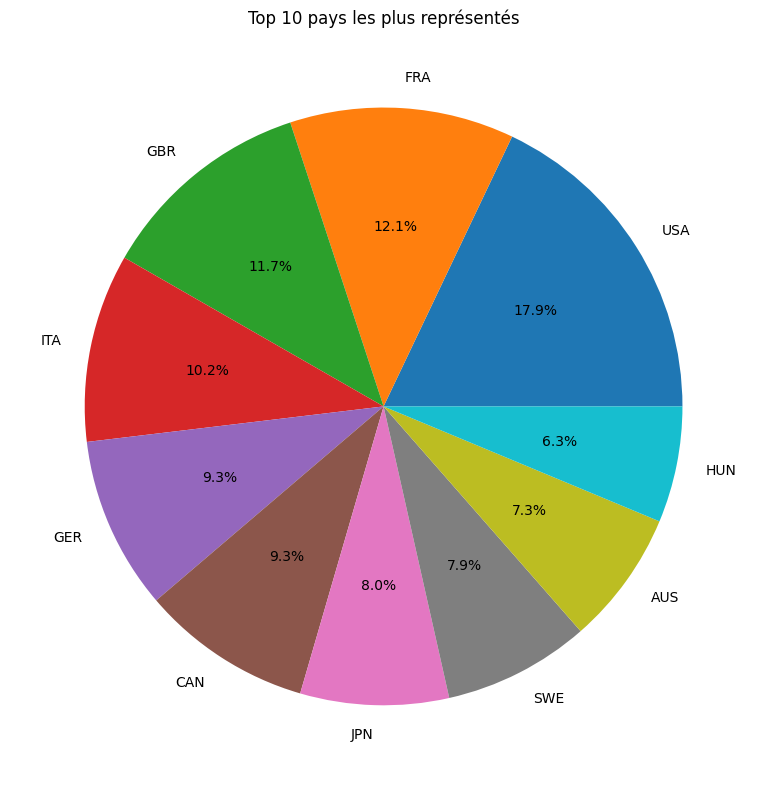

In [7]:
top10 = df["NOC"].value_counts().head(10)
print(top10)

top10.plot(kind="pie", autopct="%1.1f%%", figsize=(8, 8), title="Top 10 pays les plus représentés")
plt.ylabel("")
plt.tight_layout()
plt.show()

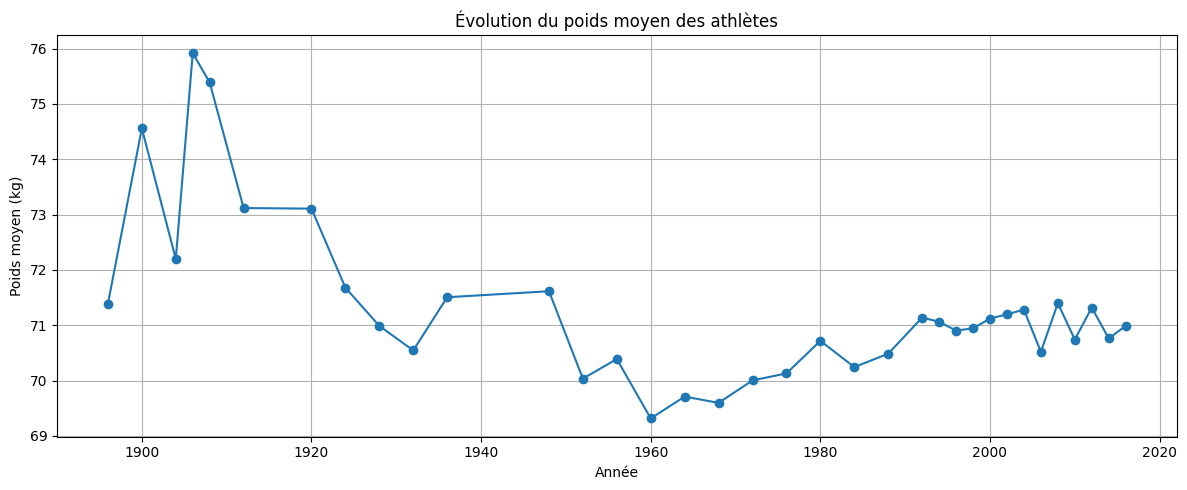

In [8]:
poids_par_annee = df.groupby("Year")["Weight"].mean()

poids_par_annee.plot(kind="line", marker="o", figsize=(12, 5), title="Évolution du poids moyen des athlètes")
plt.xlabel("Année")
plt.ylabel("Poids moyen (kg)")
plt.grid(True)
plt.tight_layout()
plt.show()

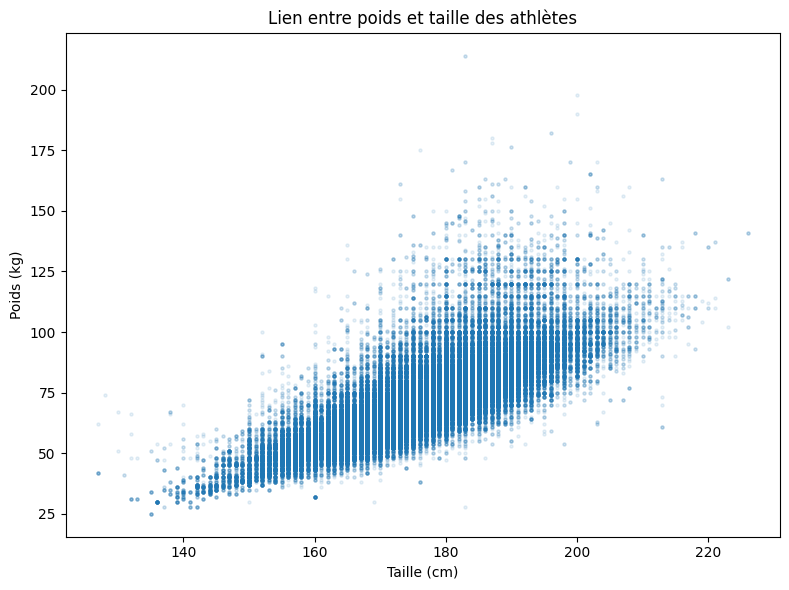

Corrélation Poids/Taille : 0.796


In [9]:
df_clean = df[["Height", "Weight"]].dropna()

plt.figure(figsize=(8, 6))
plt.scatter(df_clean["Height"], df_clean["Weight"], alpha=0.1, s=5)
plt.xlabel("Taille (cm)")
plt.ylabel("Poids (kg)")
plt.title("Lien entre poids et taille des athlètes")
plt.tight_layout()
plt.show()

print(f"Corrélation Poids/Taille : {df_clean.corr().loc['Height','Weight']:.3f}")